In [1]:
from header import *

dir="Data\Zeeman Data\data_z5\\"
i1=6100
f1=7000
i2=3800
f2=4400

<>:3: SyntaxWarning: invalid escape sequence '\Z'
<>:3: SyntaxWarning: invalid escape sequence '\Z'
C:\Users\myles\AppData\Local\Temp\ipykernel_25080\1274760492.py:3: SyntaxWarning: invalid escape sequence '\Z'
  dir="Data\Zeeman Data\data_z5\\"


Loading Files
Grouping Data
Creating first graph


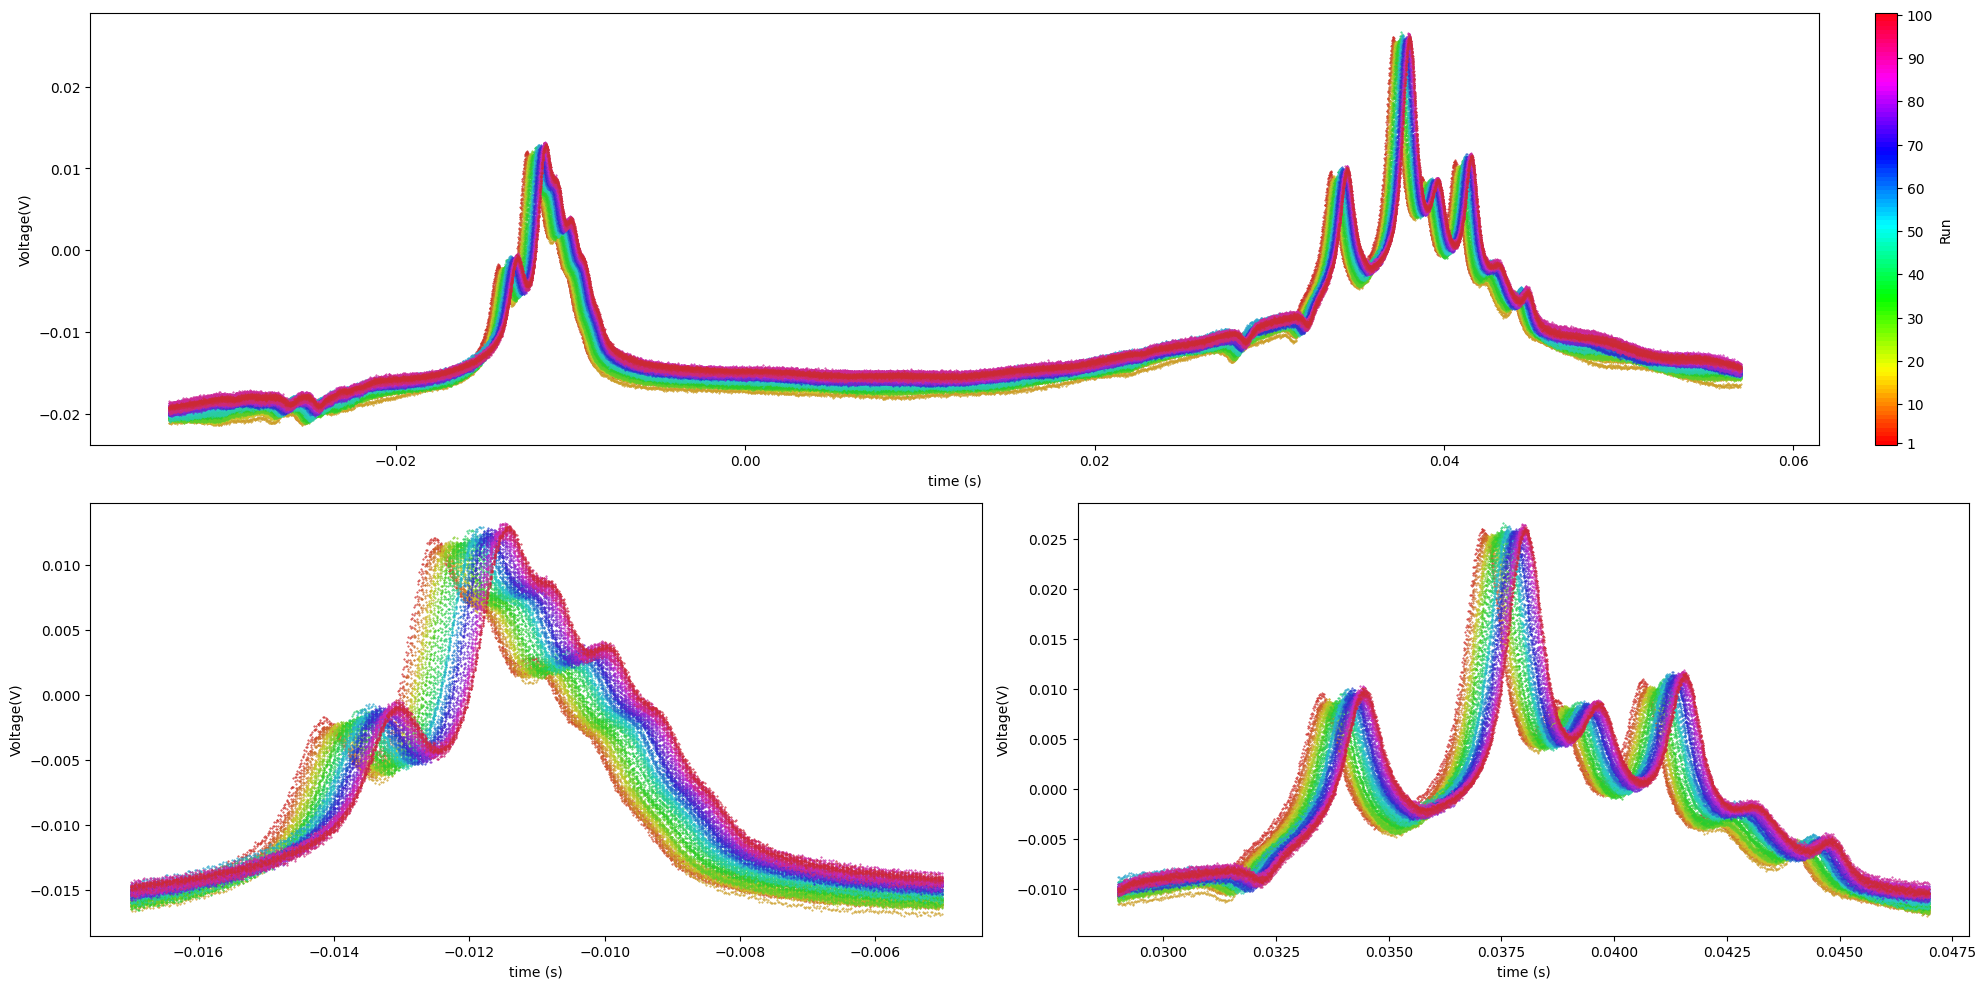

In [2]:


#load in the data
data,calibration=load(dir)

GROUP_SIZE=10
N_GROUPS=N_POINTS//GROUP_SIZE

#group the data
grouped_data=group(data,N_GROUPS,GROUP_SIZE)

print("Creating first graph")

def scale_time(t):
    return 2*10**(-6)*t+-93*10**(-3)

def scale_voltage(v):
    return 400*10**(-6)*v




#layout
fig, axs = plt.subplots(2,2,figsize=(20,10))
gs = axs[1, 1].get_gridspec()
for ax in axs[0, :]:
    ax.remove()
axbig = fig.add_subplot(gs[0, :])

#add the colour bar
fig.colorbar(cm.ScalarMappable(cmap='hsv'),ax=axbig,label="Run",ticks=[1,10,20,30,40,50,60,70,80,90,100],boundaries=np.linspace(0.5,100.5,101),values=np.linspace(0,0.99,100),fraction=0.05,pad=0.03)

#the full spectrum
for i in range(100):
    spec=scale_voltage(unp.nominal_values(grouped_data[i,3000:7500]))
    col=hsv_to_rgb((i/100,0.8,0.8))
    axbig.scatter(scale_time(np.arange(3000,7500)*GROUP_SIZE),spec,s=0.2,color=col)

for i in range(100):
    spec=scale_voltage(unp.nominal_values(grouped_data[i,i2:f2]))
    col=hsv_to_rgb((i/100,0.8,0.8))
    axs[1,0].scatter(scale_time(np.arange(i2,f2)*GROUP_SIZE),spec,s=0.2,color=col)

for i in range(100):
    spec=scale_voltage(unp.nominal_values(grouped_data[i,i1:f1]))
    col=hsv_to_rgb((i/100,0.8,0.8))
    axs[1,1].scatter(scale_time(np.arange(i1,f1)*GROUP_SIZE),spec,s=0.2,color=col)

axbig.set_xlabel("time (s)")
axs[1,0].set_xlabel("time (s)")
axs[1,1].set_xlabel("time (s)")
axbig.set_ylabel("Voltage(V)")
axs[1,0].set_ylabel("Voltage(V)")
axs[1,1].set_ylabel("Voltage(V)")

fig.tight_layout()

plt.show()

In [4]:
def lorenz(x,A,x0,gamma):
    return A/(1+((x-x0)/gamma)**2)